In [1]:
import sys 
import os
import numpy as np

import matplotlib
import geopandas as gpd 
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

sys.path.append(os.path.pardir)
from computational_grid import compute_grid

In [2]:
# ------------------------------ Load variables ------------------------------ #
# root directory
var_dir = "../data/processed"
# Lat/Lon Values of artificial grid
x = np.load(os.path.join(var_dir,"lat_lon_x.npy")) #(2618,2)
# Low regional data
pol_pt_lo = np.load(os.path.join(var_dir,"low","pol_pt_lo.npy")) #(9,2618)
pt_which_pol_lo = np.load(os.path.join(var_dir,"low","pt_which_pol_lo.npy")) #(2618,)
# High regional data 
pol_pt_hi = np.load(os.path.join(var_dir,"high","pol_pt_hi.npy")) #(49, 2618,)
pt_which_pol_hi = np.load(os.path.join(var_dir,"high","pt_which_pol_hi.npy")) #(2618,)
# Dataframes
df_lo = gpd.read_file(os.path.join(var_dir, "low", "us_census_divisions","us_census_divisions.shp"))
df_hi = gpd.read_file(os.path.join(var_dir, "high", "us_state_divisions","us_state_divisions.shp"))

In [10]:
num_grid_x = 77
# Manually look at map and decide on a grid
extents = (-125,-67,24.5,49.5)
x, grid_pts = compute_grid(num_grid_x, extents)

# Add these to grid points dataframe
grid_pts["pt_which_pol_lo"] = pt_which_pol_lo
grid_pts["pt_which_pol_hi"] = pt_which_pol_hi
grid_pts["in_out_lo"] = grid_pts["pt_which_pol_lo"].apply(lambda x: "out" if x == 0 else "in")
grid_pts["marker_size_lo"] = grid_pts["pt_which_pol_lo"].apply(lambda x: 1 if x == 0 else 5)
grid_pts["in_out_hi"] = grid_pts["pt_which_pol_hi"].apply(lambda x: "out" if x == 0 else "in")
grid_pts["marker_size_hi"] = grid_pts["pt_which_pol_hi"].apply(lambda x: 1 if x == 0 else 5)

print(f"Num Grid Points : {grid_pts.shape}")
grid_pts.head()

Num Grid Points : (2618, 9)


,Latitude,Longitude,geometry,pt_which_pol_lo,pt_which_pol_hi,in_out_lo,marker_size_lo,in_out_hi,marker_size_hi
0,24.5,-125.000000,POINT (-125 24.5),0,0,out,1,out,1
1,24.5,-124.236842,POINT (-124.23684 24.5),0,0,out,1,out,1
2,24.5,-123.473684,POINT (-123.47368 24.5),0,0,out,1,out,1
3,24.5,-122.710526,POINT (-122.71053 24.5),0,0,out,1,out,1
4,24.5,-121.947368,POINT (-121.94737 24.5),0,0,out,1,out,1


In [11]:
sns.set_style("white")

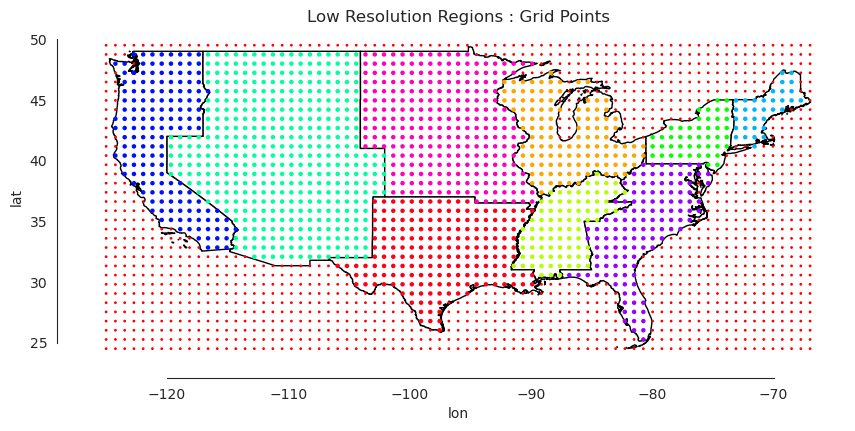

In [16]:
cmap = plt.cm.hsv
n_pol_lo =df_lo.shape[0]

fig, ax1 = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,10))
divider = make_axes_locatable(ax1)

# define the bins and normalize
bounds_lo = np.linspace(min(pt_which_pol_lo), max(pt_which_pol_lo), n_pol_lo)
norm_lo = matplotlib.colors.BoundaryNorm(bounds_lo, cmap.N)
df_lo.plot(ax=ax1, color='white', edgecolor='black')
grid_pts.plot(ax=ax1, marker='o', column='pt_which_pol_lo', markersize='marker_size_lo', cmap=cmap)
ax1.title.set_text("Low Resolution Regions : Grid Points")
ax1.set_xlabel("lon"); ax1.set_ylabel("lat")
sns.despine(offset=10, trim=True)
fig.savefig("../plots/gridpts_lo.png")


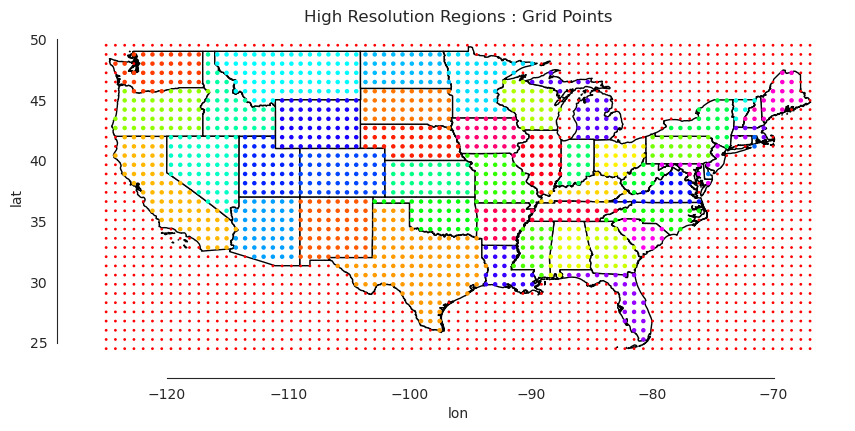

In [17]:
cmap = plt.cm.hsv
n_pol_hi =df_hi.shape[0]

fig2, ax2 = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,10))
divider = make_axes_locatable(ax2)

# define the bins and normalize
bounds_hi = np.linspace(min(pt_which_pol_hi), max(pt_which_pol_hi), n_pol_hi)
norm_hi = matplotlib.colors.BoundaryNorm(bounds_hi, cmap.N)
df_hi.plot(ax=ax2, color='white', edgecolor='black')
grid_pts.plot(ax=ax2, marker='o', column='pt_which_pol_hi', markersize='marker_size_hi', cmap=cmap)
ax2.title.set_text("High Resolution Regions : Grid Points")
ax2.set_xlabel("lon"); ax2.set_ylabel("lat")
sns.despine(offset=10, trim=True)
fig2.savefig("../plots/gridpts_hi.png")

In [17]:
n_pol_hi

49

In [18]:
df_hi

,index,area,tot_specs,tot_cases,geometry
0,0,Nebraska,3132,326,"POLYGON ((-104.05351 41.15726, -104.05267 41.2..."
1,1,Washington,9710,1077,"MULTIPOLYGON (((-122.32834 48.02134, -122.3217..."
2,2,New Mexico,3090,1088,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
3,3,South Dakota,499,290,"POLYGON ((-104.0577 44.99743, -104.05021 44.99..."
4,4,Texas,4082,531,"POLYGON ((-106.64548 31.89867, -106.64084 31.9..."
5,5,California,10547,3376,"MULTIPOLYGON (((-118.60338 33.4781, -118.59878..."
6,6,Kentucky,509,104,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ..."
7,7,Ohio,3448,1163,"MULTIPOLYGON (((-82.73571 41.60336, -82.7188 4..."
8,8,Alabama,172,22,"MULTIPOLYGON (((-88.04374 30.51742, -88.03661 ..."
9,9,Georgia,3227,1854,"POLYGON ((-85.60516 34.98468, -85.55259 34.984..."
